<a href="https://colab.research.google.com/github/hnioua/Introduction-to-Machine-Learning-/blob/main/Atelier_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from skimage.feature import canny
from skimage.transform import hough_circle, hough_circle_peaks
from skimage.draw import circle_perimeter
import numpy as np
from skimage.feature import hog
from skimage import color
import numpy as np
from skimage.feature import hog
from skimage import color
from skimage.feature import canny
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
from skimage.feature import hog
from skimage import color, feature
from skimage.feature import canny
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

In [57]:
from tensorflow.keras.datasets import cifar10

# Chargement des données d'entraînement et de test
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalisation comme en PyTorch : de [0, 255] → [-1, 1]
trainset= (x_train / 255.0 - 0.5) / 0.5
testset = (x_test / 255.0 - 0.5) / 0.5


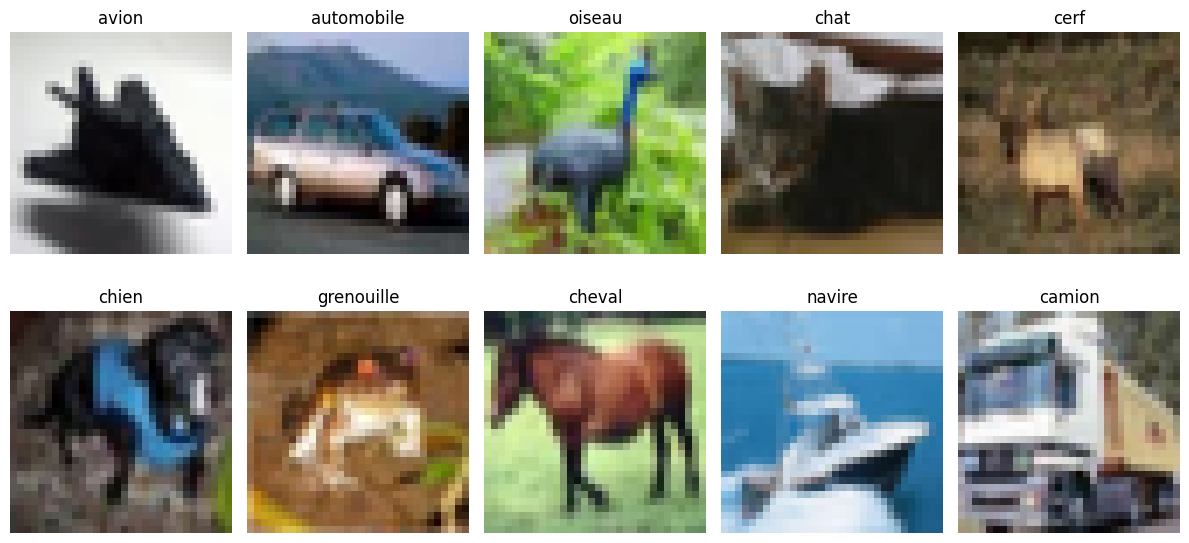

In [58]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import cifar10

# Chargement des données
(x_train, y_train), (_, _) = cifar10.load_data()

# Normalisation comme dans PyTorch
x_train_norm = (x_train / 255.0 - 0.5) / 0.5

# Liste des classes
classes = ('avion', 'automobile', 'oiseau', 'chat', 'cerf',
           'chien', 'grenouille', 'cheval', 'navire', 'camion')

# Dictionnaires pour stocker une image par classe
images_per_class = {}
count_per_class = {classname: 0 for classname in classes}

# Collecte d'une seule image par classe
for img, label in zip(x_train_norm, y_train):
    class_index = int(label[0])
    classname = classes[class_index]
    if count_per_class[classname] == 0:
        images_per_class[classname] = img
        count_per_class[classname] += 1
    if len(images_per_class) == 10:
        break

# Affichage
plt.figure(figsize=(12, 6))
for idx, classname in enumerate(classes):
    img = images_per_class[classname]

    # Dénormalisation : x = x * 0.5 + 0.5
    img = (img * 0.5) + 0.5
    img = np.clip(img, 0, 1)

    plt.subplot(2, 5, idx + 1)
    plt.imshow(img)
    plt.title(classname)
    plt.axis('off')

plt.tight_layout()
plt.show()


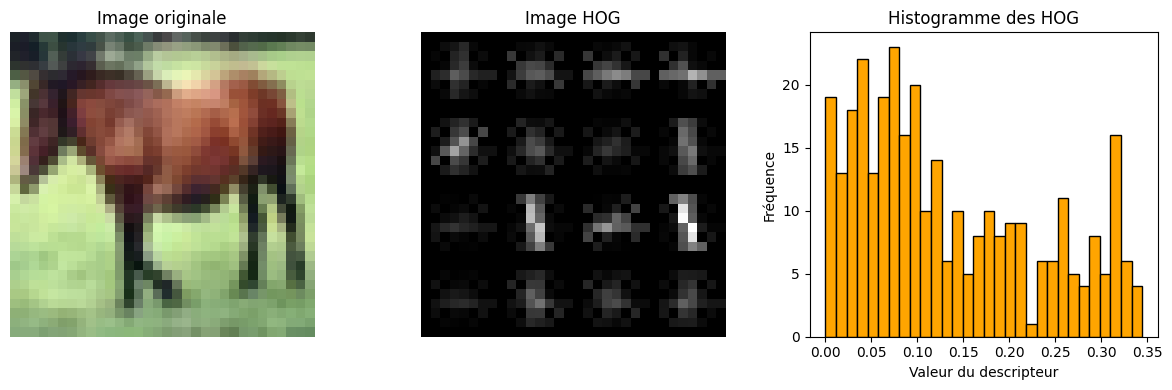

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import color
from skimage.feature import hog
from tensorflow.keras.datasets import cifar10

# Rechargement et normalisation des données
# Chargement des données d'entraînement et de test
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train_norm = (x_train / 255.0 - 0.5) / 0.5
x_test_norm = (x_test / 255.0 - 0.5) / 0.5

# Liste des classes
classes = ('avion', 'automobile', 'oiseau', 'chat', 'cerf',
           'chien', 'grenouille', 'cheval', 'navire', 'camion')

# Trouver une image de cheval
images_per_class = {}
for img, label in zip(x_train_norm, y_train):
    class_index = int(label[0])
    classname = classes[class_index]
    if classname == 'cheval':
        images_per_class['cheval'] = img
        break

# Récupérer l'image "cheval" normalisée et la dénormaliser
img = images_per_class['cheval']
npimg = (img * 0.5) + 0.5  # dénormalisation
npimg = np.clip(npimg, 0, 1)

# Conversion en niveaux de gris
gray = color.rgb2gray(npimg)

# Extraction des HOG
fd, hog_image = hog(gray,
                    orientations=9,
                    pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2),
                    visualize=True)

# Affichage
plt.figure(figsize=(12, 4))

# Image originale
plt.subplot(1, 3, 1)
plt.imshow(npimg)
plt.title('Image originale')
plt.axis('off')

# Image HOG
plt.subplot(1, 3, 2)
plt.imshow(hog_image, cmap='gray')
plt.title('Image HOG')
plt.axis('off')

# Histogramme des HOG
plt.subplot(1, 3, 3)
plt.hist(fd, bins=30, color='orange', edgecolor='black')
plt.title('Histogramme des HOG')
plt.xlabel('Valeur du descripteur')
plt.ylabel('Fréquence')

plt.tight_layout()
plt.show()


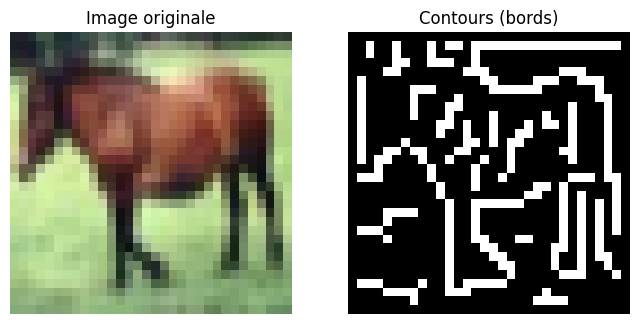

In [61]:
# Convertir en niveau de gris
gray = color.rgb2gray(npimg)

# Détecter les bords (Canny)
edges = canny(gray, sigma=1.0)

# Affichage des bords (approximation visuelle du Shape Context)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(npimg)
plt.title('Image originale')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title('Contours (bords)')
plt.axis('off')
plt.show()


In [62]:
def extraire_hog_tf(image):
    image = (image * 0.5) + 0.5  # dénormalisation
    gray = color.rgb2gray(image)
    features, _ = hog(gray,
                      orientations=9,
                      pixels_per_cell=(8, 8),
                      cells_per_block=(2, 2),
                      visualize=True)
    return features

In [63]:
def extraire_shape_context_tf(image):
    # Exemple simplifié à remplacer par une vraie extraction de Shape Context
    gray = color.rgb2gray((image * 0.5) + 0.5)
    return gray.flatten()[:128]  # juste pour illustrer

In [64]:
def appliquer_sur_dataset_tf(images, labels, fonction_extraction):
    features = []
    new_labels = []
    for img, lbl in zip(images, labels):
        feat = fonction_extraction(img)
        features.append(feat)
        new_labels.append(int(lbl[0]))
    return np.array(features), np.array(new_labels)


In [65]:
# Données d'entraînement
hog_train, labels_train = appliquer_sur_dataset_tf(trainset, y_train, extraire_hog_tf)
shape_context_train, _ = appliquer_sur_dataset_tf(trainset, y_train, extraire_shape_context_tf)

# Données de test
hog_test, labels_test = appliquer_sur_dataset_tf(testset, y_test, extraire_hog_tf)
shape_context_test, _ = appliquer_sur_dataset_tf(testset, y_test, extraire_shape_context_tf)


In [68]:
hog_train= hog_train.astype(np.float32)
hog_test= hog_test.astype(np.float32)
shape_context_train= shape_context_train.astype(np.float32)
shape_context_test= shape_context_test.astype

In [71]:
hog_train = pd.DataFrame(hog_train)
hog_test = pd.DataFrame(hog_test)
hog_train

,0,1,2,3,4,5,6,7,8,9,...,314,315,316,317,318,319,320,321,322,323
0,0.226638,0.176194,0.284600,0.092466,0.191048,0.042175,0.008676,0.034904,0.062335,0.148660,...,0.083328,0.269305,0.269305,0.269305,0.022019,0.236699,0.055783,0.228255,0.075809,0.157570
1,0.181377,0.153786,0.179297,0.251793,0.251793,0.043853,0.026397,0.025709,0.041683,0.143665,...,0.202147,0.254110,0.132265,0.029110,0.254110,0.166502,0.128123,0.120060,0.166881,0.025470
2,0.002027,0.000000,0.006148,0.000147,0.010286,0.000353,0.000000,0.000104,0.000000,0.274871,...,0.000000,0.147618,0.065686,0.038783,0.122391,0.166110,0.018045,0.017799,0.070685,0.035598
3,0.082068,0.116888,0.135197,0.115485,0.238010,0.198063,0.047301,0.036394,0.014401,0.112786,...,0.138056,0.148463,0.129848,0.182459,0.102426,0.254640,0.012364,0.058194,0.040293,0.068767
4,0.040945,0.012214,0.097817,0.148764,0.319796,0.201890,0.039217,0.010265,0.014340,0.021094,...,0.203621,0.012105,0.001720,0.006419,0.076536,0.273247,0.102015,0.008505,0.039697,0.016380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,0.161455,0.117507,0.252359,0.252359,0.252359,0.118627,0.033971,0.013416,0.081827,0.132722,...,0.003599,0.016277,0.009183,0.010019,0.048094,0.297381,0.278699,0.005406,0.012593,0.013157
49996,0.026555,0.000000,0.007570,0.053096,0.232529,0.279254,0.070561,0.007630,0.008684,0.021396,...,0.063677,0.036984,0.043429,0.043582,0.005882,0.184418,0.189651,0.055291,0.249002,0.133194
49997,0.017270,0.000000,0.000000,0.134409,0.300651,0.041559,0.052672,0.017573,0.000000,0.024984,...,0.079025,0.116570,0.012331,0.000000,0.011148,0.097264,0.068467,0.279748,0.278434,0.124738
49998,0.014042,0.000000,0.001071,0.075934,0.364902,0.082193,0.011431,0.003206,0.000000,0.009092,...,0.114043,0.173457,0.075296,0.245874,0.157201,0.245874,0.061887,0.074277,0.194720,0.164869


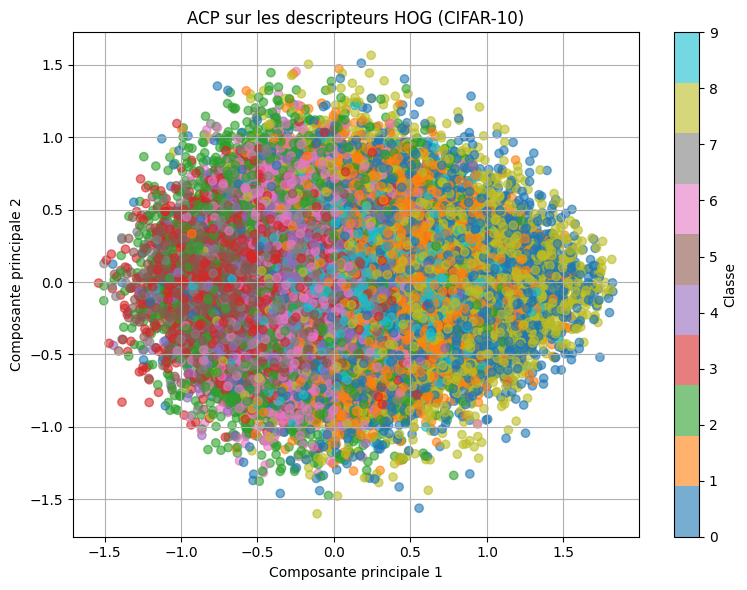

In [72]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Réduction à 2 composantes principales
pca = PCA(n_components=2)
hog_train_pca = pca.fit_transform(hog_train)

# Affichage des résultats avec les labels
plt.figure(figsize=(8,6))
scatter = plt.scatter(hog_train_pca[:, 0], hog_train_pca[:, 1], c=y_train.flatten(), cmap='tab10', alpha=0.6)
plt.colorbar(scatter, ticks=range(10), label='Classe')
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.title("ACP sur les descripteurs HOG (CIFAR-10)")
plt.grid(True)
plt.tight_layout()
plt.show()


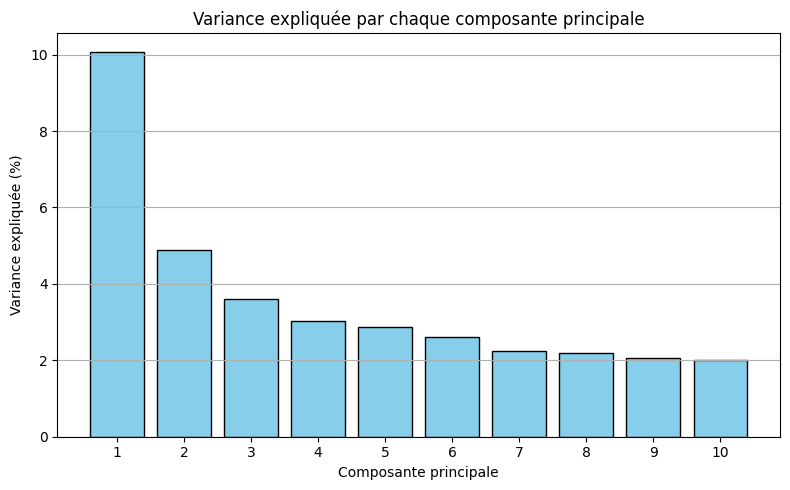

In [74]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Appliquer PCA avec plus de composantes pour visualiser la variance
pca_full = PCA(n_components=10)  # Par exemple, 10 composantes
pca_full.fit(hog_train)

# Variance expliquée
explained_var = pca_full.explained_variance_ratio_

# Affichage
plt.figure(figsize=(8,5))
plt.bar(range(1, len(explained_var) + 1), explained_var * 100, color='skyblue', edgecolor='black')
plt.xlabel('Composante principale')
plt.ylabel('Variance expliquée (%)')
plt.title("Variance expliquée par chaque composante principale")
plt.grid(axis='y')
plt.xticks(np.arange(1, len(explained_var) + 1))
plt.tight_layout()
plt.show()


In [73]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.decomposition import PCA

# 1. Appliquer PCA sur les données d'entraînement
pca = PCA(n_components=2)
hog_train_pca = pca.fit_transform(hog_train)

# 2. Appliquer la même transformation PCA sur les données de test
hog_test_pca = pca.transform(hog_test)

# 3. Entraînement du modèle Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(hog_train_pca, y_train.flatten())

# 4. Prédictions sur les données de test
y_pred = clf.predict(hog_test_pca)

# 5. Évaluation
print("Précision globale :", accuracy_score(y_test, y_pred))
print("\nRapport de classification :\n", classification_report(y_test, y_pred, target_names=classes))


Précision globale : 0.1877

Rapport de classification :
               precision    recall  f1-score   support

       avion       0.22      0.21      0.22      1000
  automobile       0.23      0.25      0.24      1000
      oiseau       0.17      0.16      0.16      1000
        chat       0.17      0.17      0.17      1000
        cerf       0.13      0.12      0.12      1000
       chien       0.22      0.24      0.23      1000
  grenouille       0.18      0.18      0.18      1000
      cheval       0.13      0.13      0.13      1000
      navire       0.27      0.27      0.27      1000
      camion       0.15      0.16      0.16      1000

    accuracy                           0.19     10000
   macro avg       0.19      0.19      0.19     10000
weighted avg       0.19      0.19      0.19     10000



In [69]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

#Entraînement avec la stratégie traditionnelle



#1. HOG Features




# Arbre de décision

In [56]:
dt_hog = DecisionTreeClassifier()
dt_hog.fit(hog_train, trainset.targets)  # Utiliser hog_train et trainset.targets
y_pred_dt_hog = dt_hog.predict(hog_test)  # Prédictions sur hog_test
accuracy_dt_hog = accuracy_score(testset.targets, y_pred_dt_hog)  # Évaluation sur testset.targets

# Forêts aléatoires

In [11]:
rf_hog = RandomForestClassifier()
rf_hog.fit(hog_train, trainset.targets)
y_pred_rf_hog = rf_hog.predict(hog_test)
accuracy_rf_hog = accuracy_score(testset.targets, y_pred_rf_hog)

# 2. Shape Context Features

# Arbre de décision

In [12]:
dt_shape = DecisionTreeClassifier()
dt_shape.fit(shape_context_train, trainset.targets)
y_pred_dt_shape = dt_shape.predict(shape_context_test)
accuracy_dt_shape = accuracy_score(testset.targets, y_pred_dt_shape)

# Forêts aléatoires

In [13]:
rf_shape = RandomForestClassifier()
rf_shape.fit(shape_context_train, trainset.targets)
y_pred_rf_shape = rf_shape.predict(shape_context_test)
accuracy_rf_shape = accuracy_score(testset.targets, y_pred_rf_shape)

# Entraînement avec la validation croisée

# 1. HOG Features


# Arbre de décision

In [14]:
dt_hog_cv = DecisionTreeClassifier()
scores_dt_hog = cross_val_score(dt_hog_cv, hog_train, trainset.targets, cv=5)  # Utiliser hog_train et trainset.targets
mean_accuracy_dt_hog_cv = scores_dt_hog.mean()

# Forêts aléatoires

In [15]:
rf_hog_cv = RandomForestClassifier()
scores_rf_hog = cross_val_score(rf_hog_cv, hog_train, trainset.targets, cv=5)
mean_accuracy_rf_hog_cv = scores_rf_hog.mean()

# 2. Shape Context Features

# Arbre de décision

In [16]:
dt_shape_cv = DecisionTreeClassifier()
scores_dt_shape = cross_val_score(dt_shape_cv, shape_context_train, trainset.targets, cv=5)
mean_accuracy_dt_shape_cv = scores_dt_shape.mean()

# Forêts aléatoires

In [ ]:
rf_shape_cv = RandomForestClassifier()
scores_rf_shape = cross_val_score(rf_shape_cv, shape_context_train, trainset.targets, cv=5)
mean_accuracy_rf_shape_cv = scores_rf_shape.mean()

# --- Matrice de confusion pour la stratégie traditionnelle ---

# 1. HOG Features (Arbre de décision)

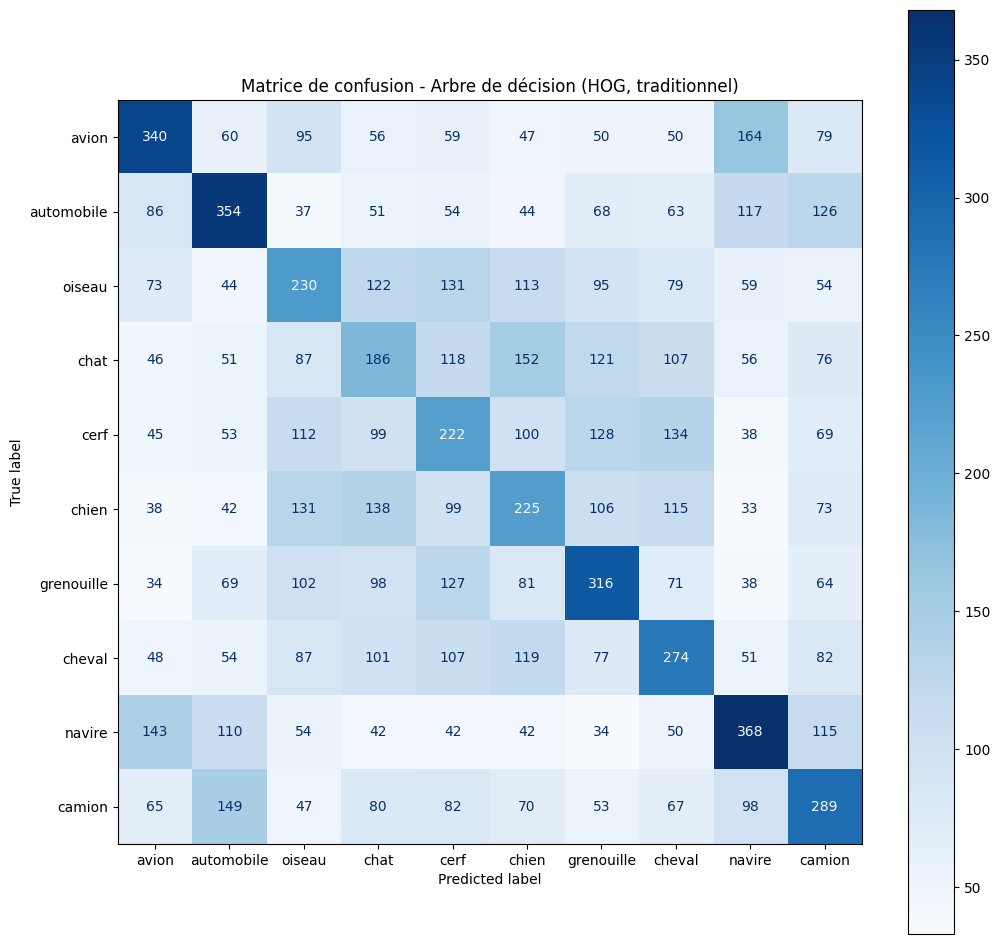

In [18]:
cm_dt_hog = confusion_matrix(testset.targets, y_pred_dt_hog)
disp_dt_hog = ConfusionMatrixDisplay(confusion_matrix=cm_dt_hog, display_labels=classes)

plt.figure(figsize=(12, 12))  # Correct pour définir la taille
disp_dt_hog.plot(cmap=plt.cm.Blues, ax=plt.gca())  # Utiliser l'axe courant
plt.title("Matrice de confusion - Arbre de décision (HOG, traditionnel)")
plt.show()


# 2. HOG Features (Forêts aléatoires)

In [ ]:
cm_rf_hog = confusion_matrix(testset.targets, y_pred_rf_hog)
disp_rf_hog = ConfusionMatrixDisplay(confusion_matrix=cm_rf_hog, display_labels=classes)

plt.figure(figsize=(12, 12))  # Correct pour définir la taille
disp_rf_hog.plot(cmap=plt.cm.Blues, ax=plt.gca())  # Utiliser l'axe courant
plt.title("Matrice de confusion - Forêts aléatoires (HOG, traditionnel)")
plt.show()

# 3. Shape Context Features (Arbre de décision)


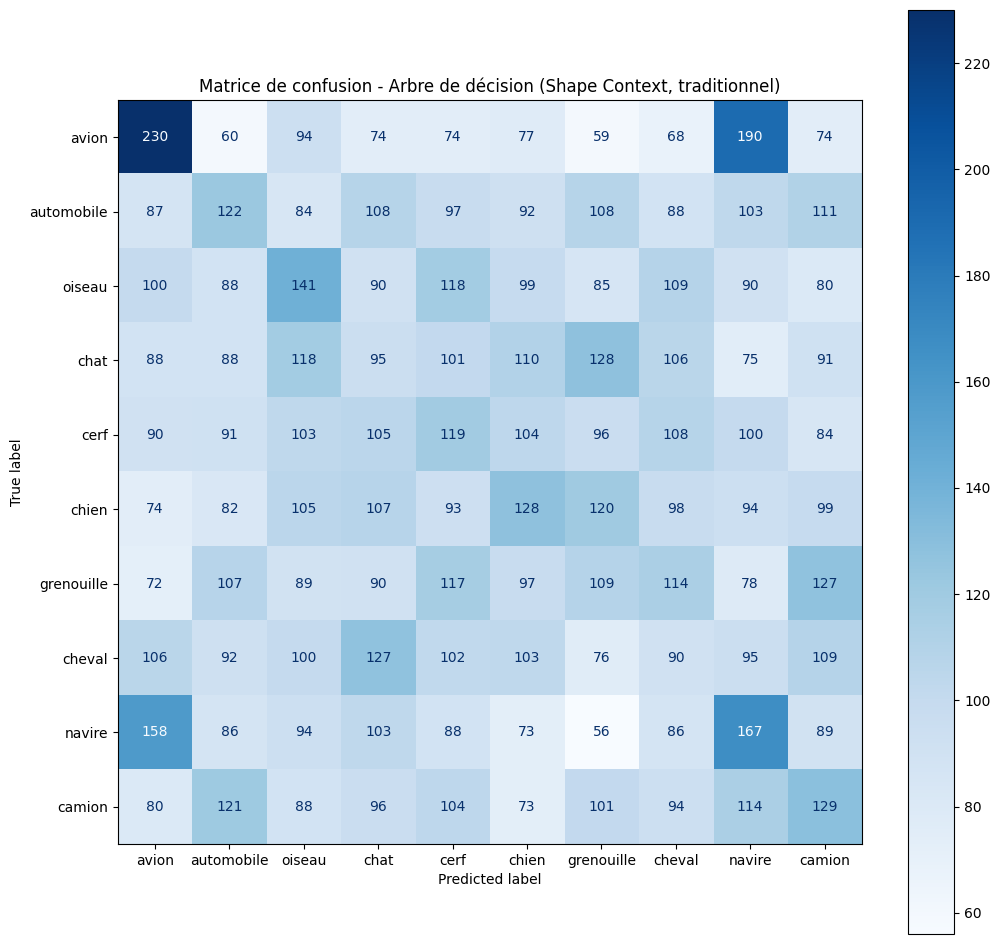

In [20]:
cm_dt_shape = confusion_matrix(testset.targets, y_pred_dt_shape)
disp_dt_shape = ConfusionMatrixDisplay(confusion_matrix=cm_dt_shape, display_labels=classes)

plt.figure(figsize=(12, 12))  # Correct pour définir la taille
disp_dt_shape.plot(cmap=plt.cm.Blues, ax=plt.gca())  # Utiliser l'axe courant
plt.title("Matrice de confusion - Arbre de décision (Shape Context, traditionnel)")
plt.show()


# 4. Shape Context Features (Forêts aléatoires)

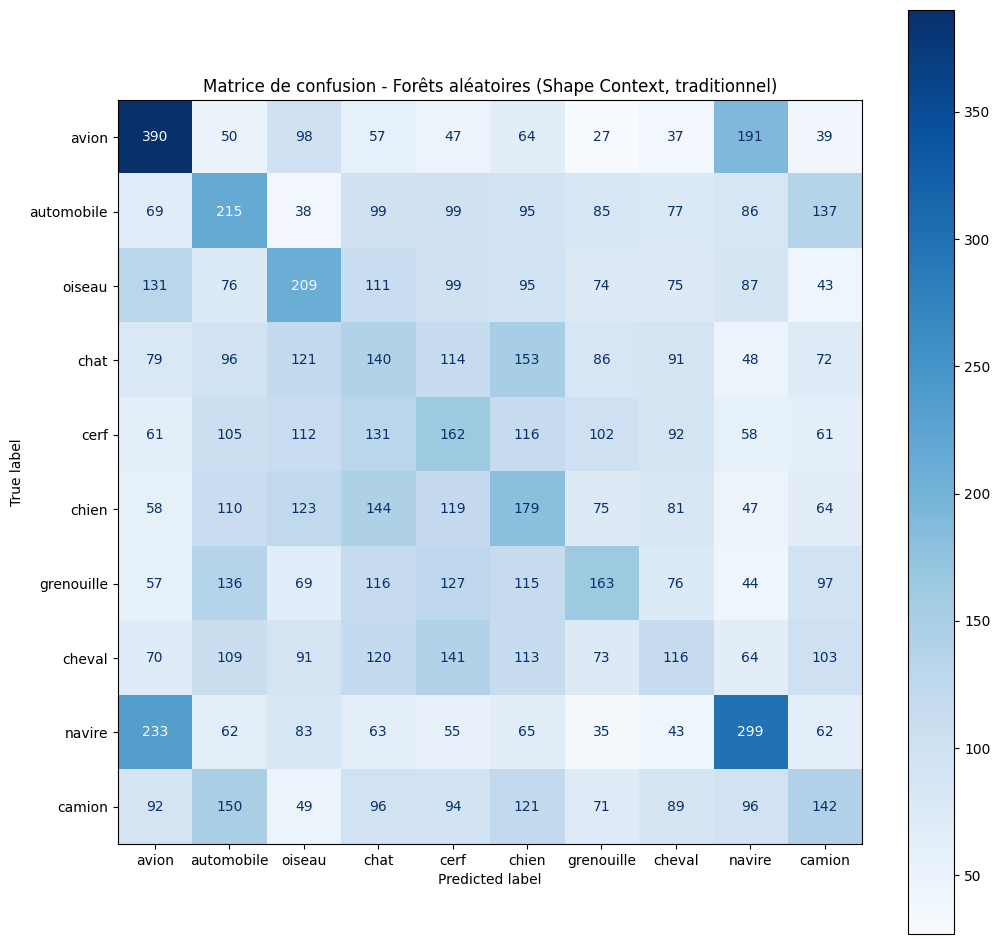

In [21]:
cm_rf_shape = confusion_matrix(testset.targets, y_pred_rf_shape)
disp_rf_shape = ConfusionMatrixDisplay(confusion_matrix=cm_rf_shape, display_labels=classes)

plt.figure(figsize=(12, 12))  # Correct pour définir la taille
disp_rf_shape.plot(cmap=plt.cm.Blues, ax=plt.gca())  # Utiliser l'axe courant
plt.title("Matrice de confusion - Forêts aléatoires (Shape Context, traditionnel)")
plt.show()


# --- Matrice de confusion pour la validation croisée ---

# 1. HOG Features (Arbre de décision)

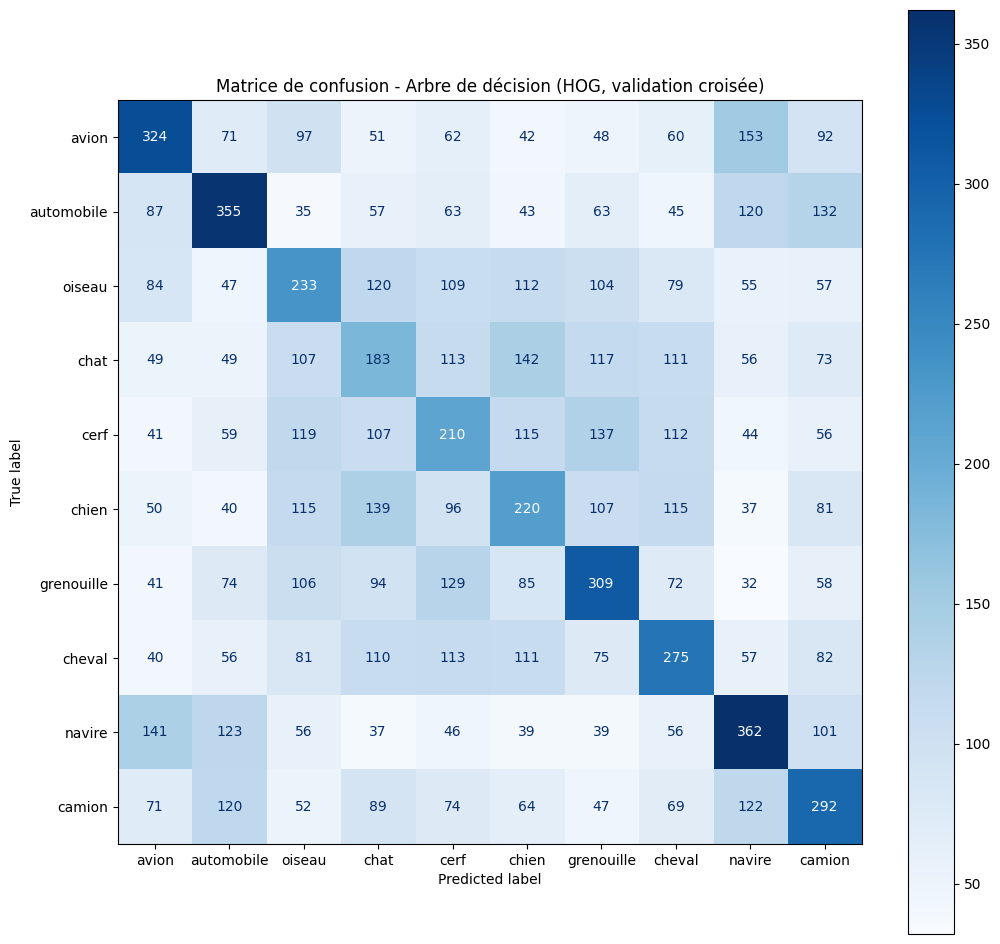

In [22]:
dt_hog_cv.fit(hog_train, trainset.targets)
y_pred_dt_hog_cv = dt_hog_cv.predict(hog_test)
cm_dt_hog_cv = confusion_matrix(testset.targets, y_pred_dt_hog_cv)
disp_dt_hog_cv = ConfusionMatrixDisplay(confusion_matrix=cm_dt_hog_cv, display_labels=classes)

plt.figure(figsize=(12, 12))  # Correct pour définir la taille
disp_dt_hog_cv.plot(cmap=plt.cm.Blues, ax=plt.gca())  # Utiliser l'axe courant
plt.title("Matrice de confusion - Arbre de décision (HOG, validation croisée)")
plt.show()

# 2. HOG Features (Forêts aléatoires)

In [ ]:
rf_hog_cv.fit(hog_train, trainset.targets)
y_pred_rf_hog_cv = rf_hog_cv.predict(hog_test)
cm_rf_hog_cv = confusion_matrix(testset.targets, y_pred_rf_hog_cv)
disp_rf_hog_cv = ConfusionMatrixDisplay(confusion_matrix=cm_rf_hog_cv, display_labels=classes)

plt.figure(figsize=(12, 12))  # Correct pour définir la taille
disp_rf_hog_cv.plot(cmap=plt.cm.Blues, ax=plt.gca())  # Utiliser l'axe courant
plt.title("Matrice de confusion - Forêts aléatoires (HOG, validation croisée)")
plt.show()

# 3. Shape Context Features (Arbre de décision)


In [ ]:
dt_shape_cv.fit(shape_context_train, trainset.targets)
y_pred_dt_shape_cv = dt_shape_cv.predict(shape_context_test)
cm_dt_shape_cv = confusion_matrix(testset.targets, y_pred_dt_shape_cv)
disp_dt_shape_cv = ConfusionMatrixDisplay(confusion_matrix=cm_dt_shape_cv, display_labels=classes)

plt.figure(figsize=(12, 12))  # Correct pour définir la taille
disp_dt_shape_cv.plot(cmap=plt.cm.Blues, ax=plt.gca())  # Utiliser l'axe courant
plt.title("Matrice de confusion - Arbre de décision (Shape Context, validation croisée)")
plt.show()

# 4. Shape Context Features (Forêts aléatoires)

In [ ]:
rf_shape_cv.fit(shape_context_train, trainset.targets)
y_pred_rf_shape_cv = rf_shape_cv.predict(shape_context_test)
cm_rf_shape_cv = confusion_matrix(testset.targets, y_pred_rf_shape_cv)
disp_rf_shape_cv = ConfusionMatrixDisplay(confusion_matrix=cm_rf_shape_cv, display_labels=classes)

plt.figure(figsize=(12, 12))  # Correct pour définir la taille
disp_rf_shape_cv.plot(cmap=plt.cm.Blues, ax=plt.gca())  # Utiliser l'axe courant
plt.title("Matrice de confusion - Forêts aléatoires (Shape Context, validation croisée)")
plt.show()

## Evaluer la performance de l’Arbre de décision et Forêts aléatoires, en utilisant les métriques :
## Rappel, Précision, F-score, et Taux d’erreur.  

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Fonction pour calculer les métriques et construire le DataFrame
def evaluer_modele(y_true, y_pred, nom_modele):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    taux_erreur = 1 - accuracy

    metrics = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Taux d'erreur": taux_erreur
    }

    return pd.DataFrame([metrics], index=[nom_modele])

# Évaluer les modèles et construire le DataFrame
resultats = pd.concat([
    evaluer_modele(testset.targets, y_pred_dt_hog, "Arbre de décision (HOG, traditionnel)"),
    evaluer_modele(testset.targets, y_pred_rf_hog, "Forêts aléatoires (HOG, traditionnel)"),
    evaluer_modele(testset.targets, y_pred_dt_shape, "Arbre de décision (Shape Context, traditionnel)"),
    evaluer_modele(testset.targets, y_pred_rf_shape, "Forêts aléatoires (Shape Context, traditionnel)"),
    # --- Évaluations pour la validation croisée ---
    evaluer_modele(testset.targets, y_pred_dt_hog_cv, "Arbre de décision (HOG, validation croisée)"),
    evaluer_modele(testset.targets, y_pred_rf_hog_cv, "Forêts aléatoires (HOG, validation croisée)"),
    evaluer_modele(testset.targets, y_pred_dt_shape_cv, "Arbre de décision (Shape Context, validation croisée)"),
    evaluer_modele(testset.targets, y_pred_rf_shape_cv, "Forêts aléatoires (Shape Context, validation croisée)")
])

# Afficher le DataFrame
display(resultats)